# HW4 Lab

We have seen rootfinding methods that have linear, superlinear, and quadratic convergence. We know that the bisection method has at least linear convergence, the secant method has superlinear convergence, and Newton's method has quadratic convergence.  These are ordered from slowest to fastest.  In fact, quadratic convergence can be dramatically faster than linear convergence.  Today we'll explore this fact by implementing these methods, testing them on a given rootfinding problem, and plotting the errors!

In [1]:
using Plots

### (a)

 Implement the bisection method in Julia.  Make sure to return a vector `x` that contains as entries the approximations $x_k$. 

In [ ]:
# implement bisection method
# returns approximations from all iterations
# xtol and ftol are absolute tolerances for x and f(x)
# maxIter is the maximum number of iterations
function bisection(f, a, b, ftol = 10*eps(), xtol = 10*eps(), maxIter = 100)
    # check if f(a) and f(b) have different signs
    if f(a) * f(b) > 0
        error("f(a) and f(b) must have different signs")
    end

    # initialize variables
    c = (a + b) / 2
    iterations = []

    for i in 1:maxIter
        # store the current approximation
        push!(iterations, c)

        # check if the root is found or if the tolerance is met
        if abs(f(c)) < ftol || abs(b - a) < xtol
            break
        end

        # update the interval based on the sign of f(c)
        if f(c) * f(a) < 0
            b = c
        else
            a = c
        end

        # recalculate c
        c = (a + b) / 2
    end

    return iterations
end

bisection (generic function with 4 methods)

### (b)

Define $f(x) = \frac{1}{x-3} - 6$ in Julia and create a plot of this function over the interval $[3.1, 3.4]$.  Notice that there is a root at $19/6$.

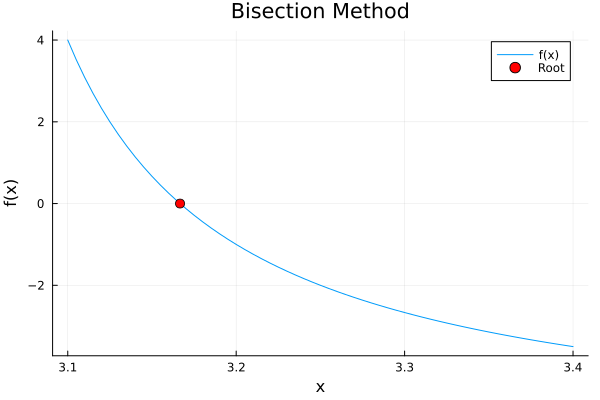

In [3]:
# define f
f(x) = 1 / (x - 3) - 6

# create plot of function
x = 3.1:0.005:3.4
y = f.(x)
plot(x, y, label="f(x)", title="Bisection Method", xlabel="x", ylabel="f(x)", legend=:topright)
plot!([19/6], [0], seriestype=:scatter, label="Root", color=:red, markersize=5) # add root to plot

### (c)

Apply the bisection method (initialized with $a_1 = 3.1$ and $b_1 = 3.5$), the secant method (initialized with $x_1 = 3.5$ and $x_2 = 3.1$), and Newton's method (initialized with $x_1 = 3.1$) to approximate this root.  You may copy the code for the secant method and Newton's method from our class notes.  (Each of these methods should converge with this proper initialization.) 

In [ ]:
# secant
# xtol and ftol are absolute tolerances for x and f(x)
# maxIter is the maximum number of iterations
function secant(f, x0, x1, ftol = 10*eps(), xtol = 10*eps(), maxIter = 100)
    xs = [x0, x1]

    for i in 2:maxIter+1
        # check if the function values are close enough
        if abs(f(xs[i])) < ftol || abs(xs[i] - xs[i-1]) < xtol
            break
        end

        # calculate the next approximation using the secant method
        x_next = xs[i] - f(xs[i]) * (xs[i] - xs[i-1]) / (f(xs[i]) - f(xs[i-1]))
        push!(xs, x_next)
    end

    return xs
end

# newton's method
# xtol and ftol are absolute tolerances for x and f(x)
# maxIter is the maximum number of iterations
function newton(f, f_prime, x0, ftol = 10*eps(), xtol = 10*eps(), maxIter = 100)
    xs = [x0]
    # check if the derivative is not zero at the initial point
    if f_prime(x0) == 0
        error("Derivative is zero at the initial point")
    end

    push!(xs, xs[1] - f(xs[1]) / f_prime(xs[1]))

    for i in 2:maxIter+1
        # check if the function value is close enough
        if abs(f(xs[i])) < ftol || abs(xs[i] - xs[i-1]) < xtol
            break
        end

        # calculate the next approximation using Newton's method
        x_next = xs[i] - f(xs[i]) / f_prime(xs[i])
        push!(xs, x_next)
    end

    return xs
end

# derivative of f
f_prime(x) = -1 / ((x - 3)^2)

f_prime (generic function with 1 method)

In [5]:
# use the three methods to find the root
root_bisection = bisection(f, 3.1, 3.4)
root_secant = secant(f, 3.5, 3.1)
root_newton = newton(f, f_prime, 3.1)

# print the final approximations
println("Bisection method root: ", root_bisection[end])
println("Secant method root: ", root_secant[end])
println("Newton's method root: ", root_newton[end])

Bisection method root: 3.166666666666667
Secant method root: 3.1666666666666665
Newton's method root: 3.1666666666666665


### (d) / (e)

Let $r = 19/6$ and calculate the errors $\epsilon_k = x_k - r$ for each method.  (You should have a vector of errors for each method, each with as many entries as iterations were run for that method.)

Create a single log-linear plot (yscale is logarithmic) which plots the magnitude of the errors for each of these methods.  (Exclude any error values that are 0.)

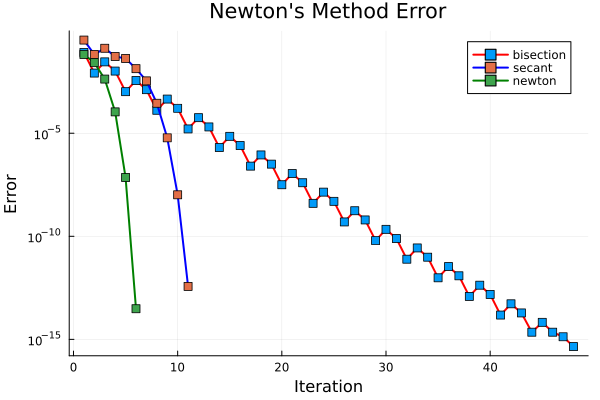

In [6]:
r = 19/6

# calculate erros
bisection_error = [abs(r - x) for x in root_bisection]
secant_error = [abs(r - x) for x in root_secant]
newton_error = [abs(r - x) for x in root_newton]

# plot errors, skip the ones that are too small
bisection_error = [x for x in bisection_error if x > eps()]
secant_error = [x for x in secant_error if x > eps()]
newton_error = [x for x in newton_error if x > eps()]

# plot the errors in scatter plot connected by lines
plot(bisection_error,
     title="Bisection Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="bisection",
     legend=:topright, 
     grid=true, 
     marker=:square, 
     linecolor=:red, 
     linewidth=2)
plot!(secant_error,
     title="Secant Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="secant",
     marker=:square, 
     linecolor=:blue, 
     linewidth=2)
plot!(newton_error,
     title="Newton's Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="newton",
     marker=:square, 
     linecolor=:green, 
     linewidth=2)

As we can see, Newton's method converges the fasted, followed by secant and then bisection.